In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3', 'FC1'])",
 1: 'Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=[])',
 2: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3'])",
 3: 'Classifier_3 (n_neurons_molt_factor=1, do_dropout=[])',
 4: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 5: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3'])",
 6: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2'])",
 7: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 8: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3'])",
 9: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3', 'FC1'])",
 10: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'FC1'])",
 11: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3', 'FC1'])",
 12: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])",
 13: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Co

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,5,0.00,0.980340,0.082041,34.751964
1,1,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,5,0.25,0.976854,0.081980,5.830103
2,2,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,5,0.50,0.984802,0.081813,6.931423
3,3,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,5,0.75,0.996235,0.081638,43.421904
4,4,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,10,0.00,0.992610,0.081659,45.212873
5,5,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,10,0.25,0.995956,0.081491,30.662220
6,6,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,10,0.50,0.994980,0.081479,20.898624
7,7,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,10,0.75,0.995956,0.081575,48.210520
8,8,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,15,0.00,0.996793,0.081696,25.546714
9,9,0,1.0,"['Conv2', 'Conv3', 'FC1']",0.0005,32,15,0.25,0.996375,0.081678,62.620337


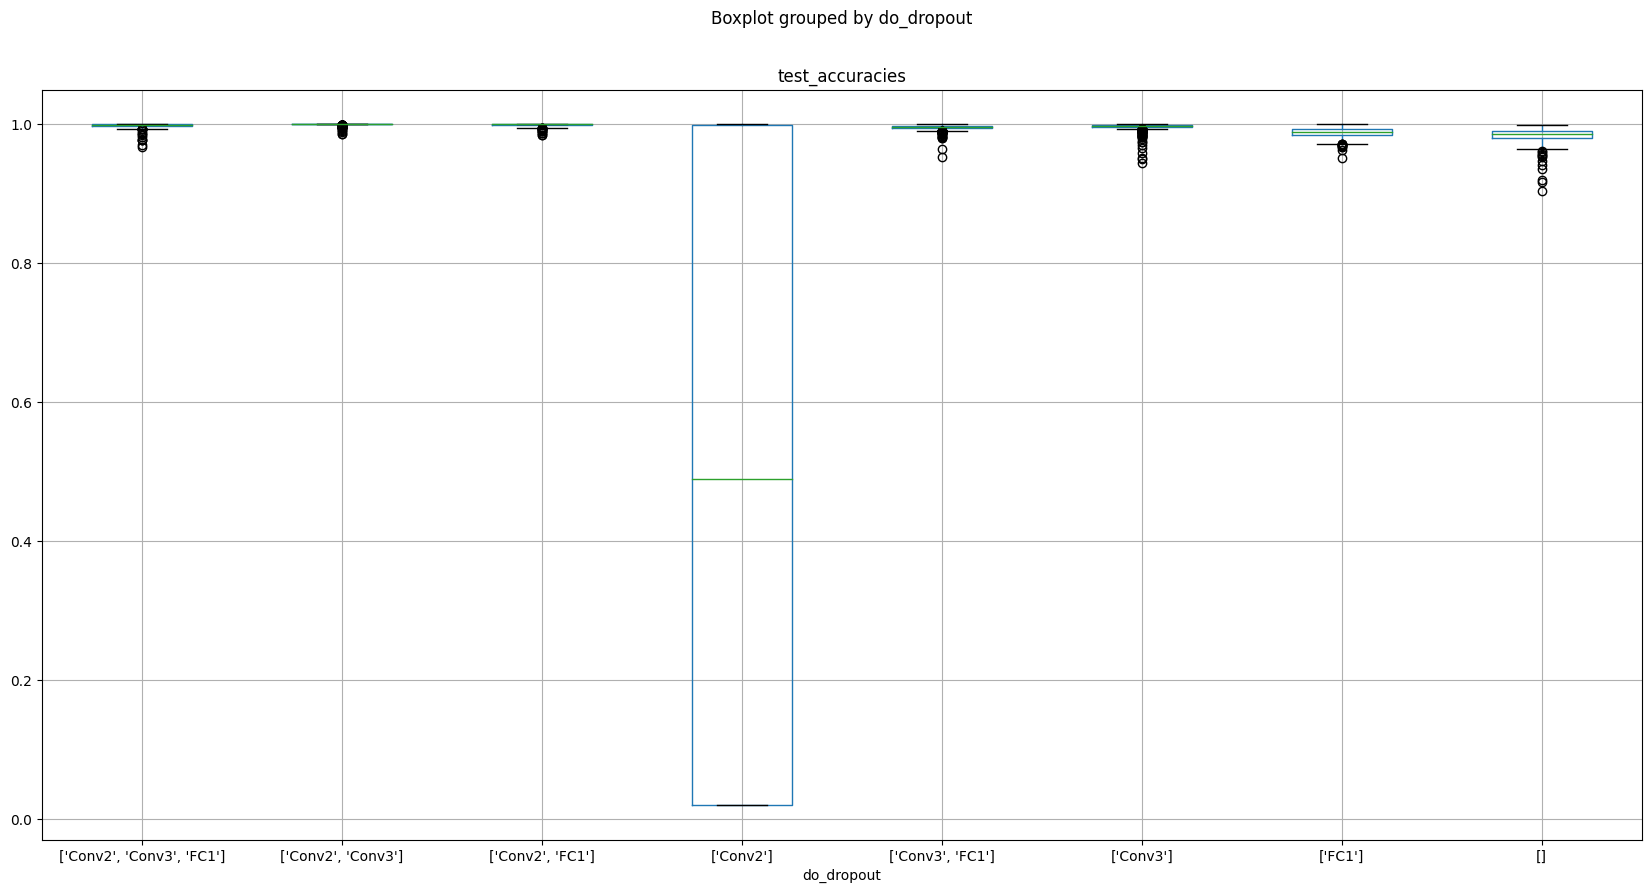

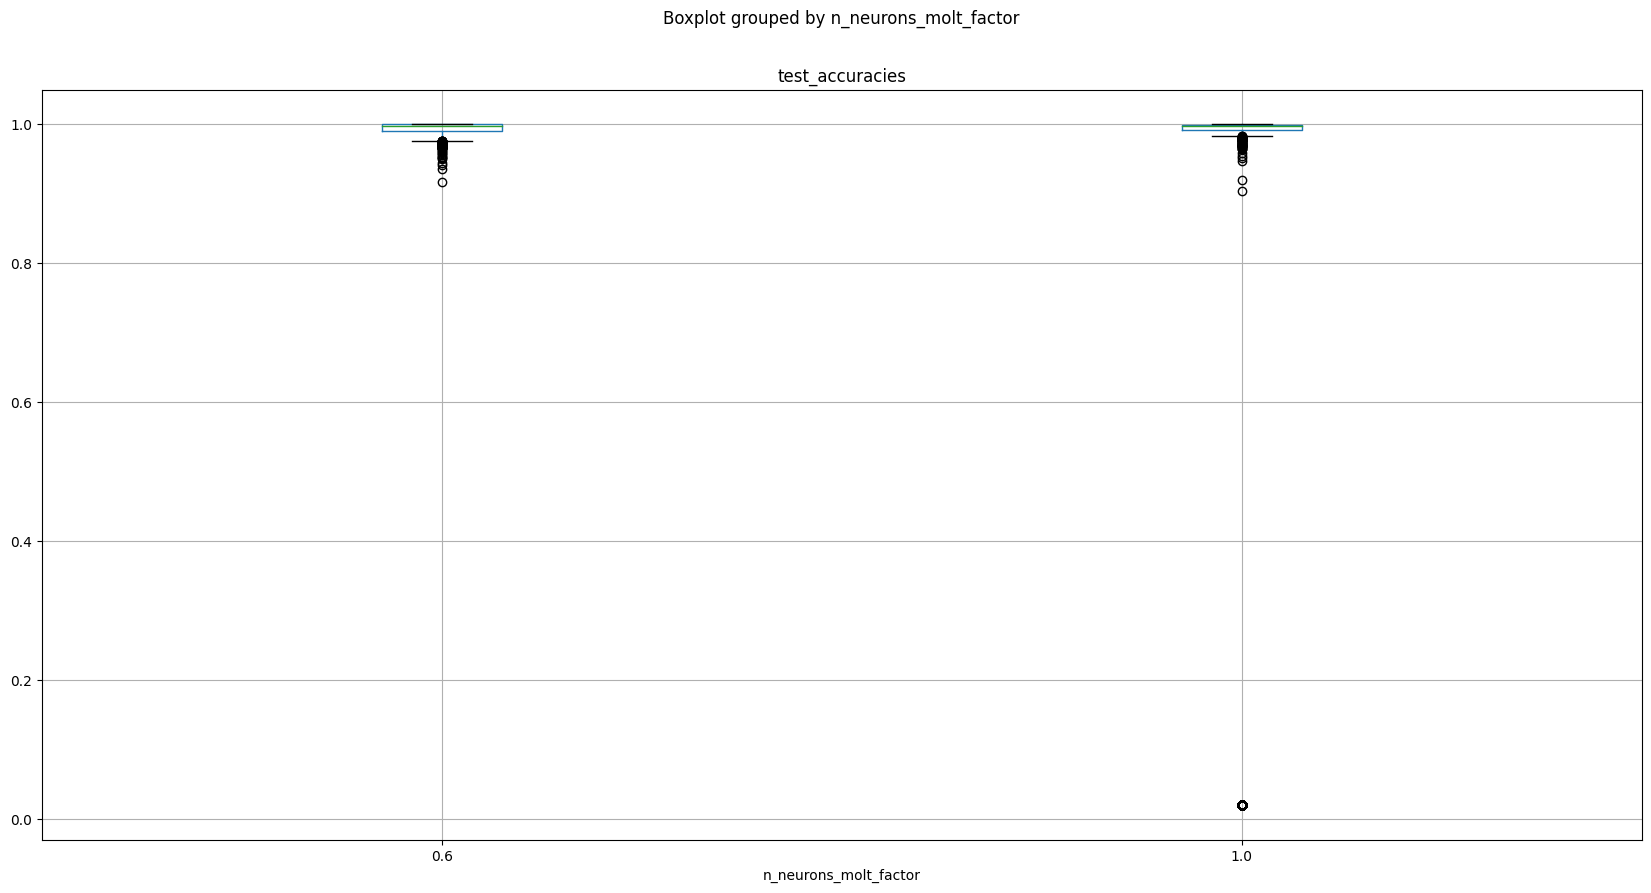

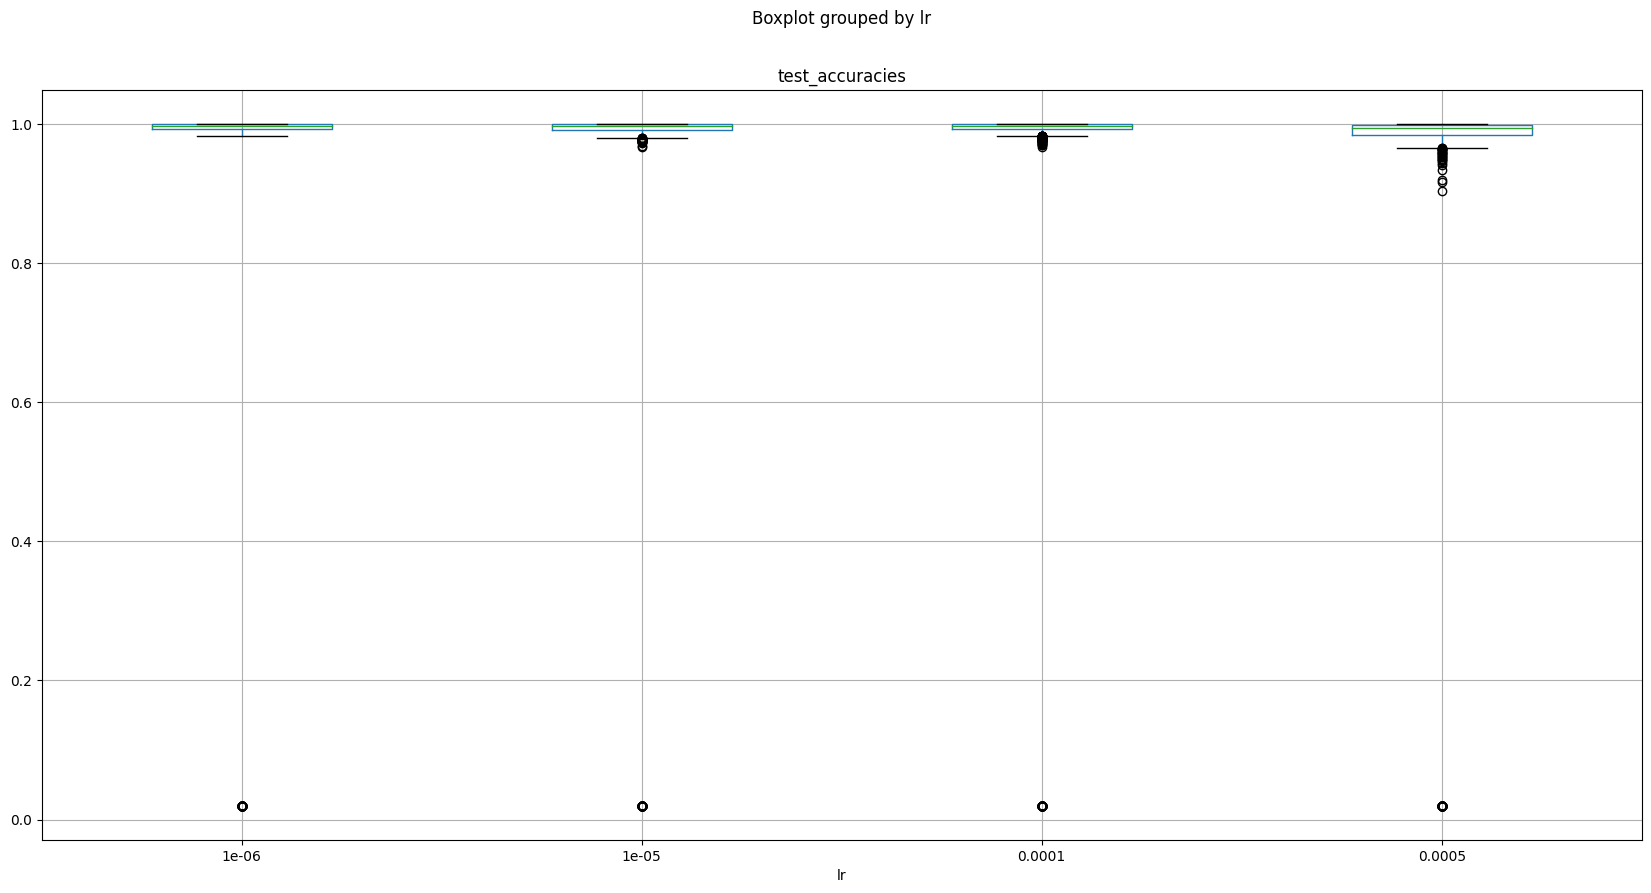

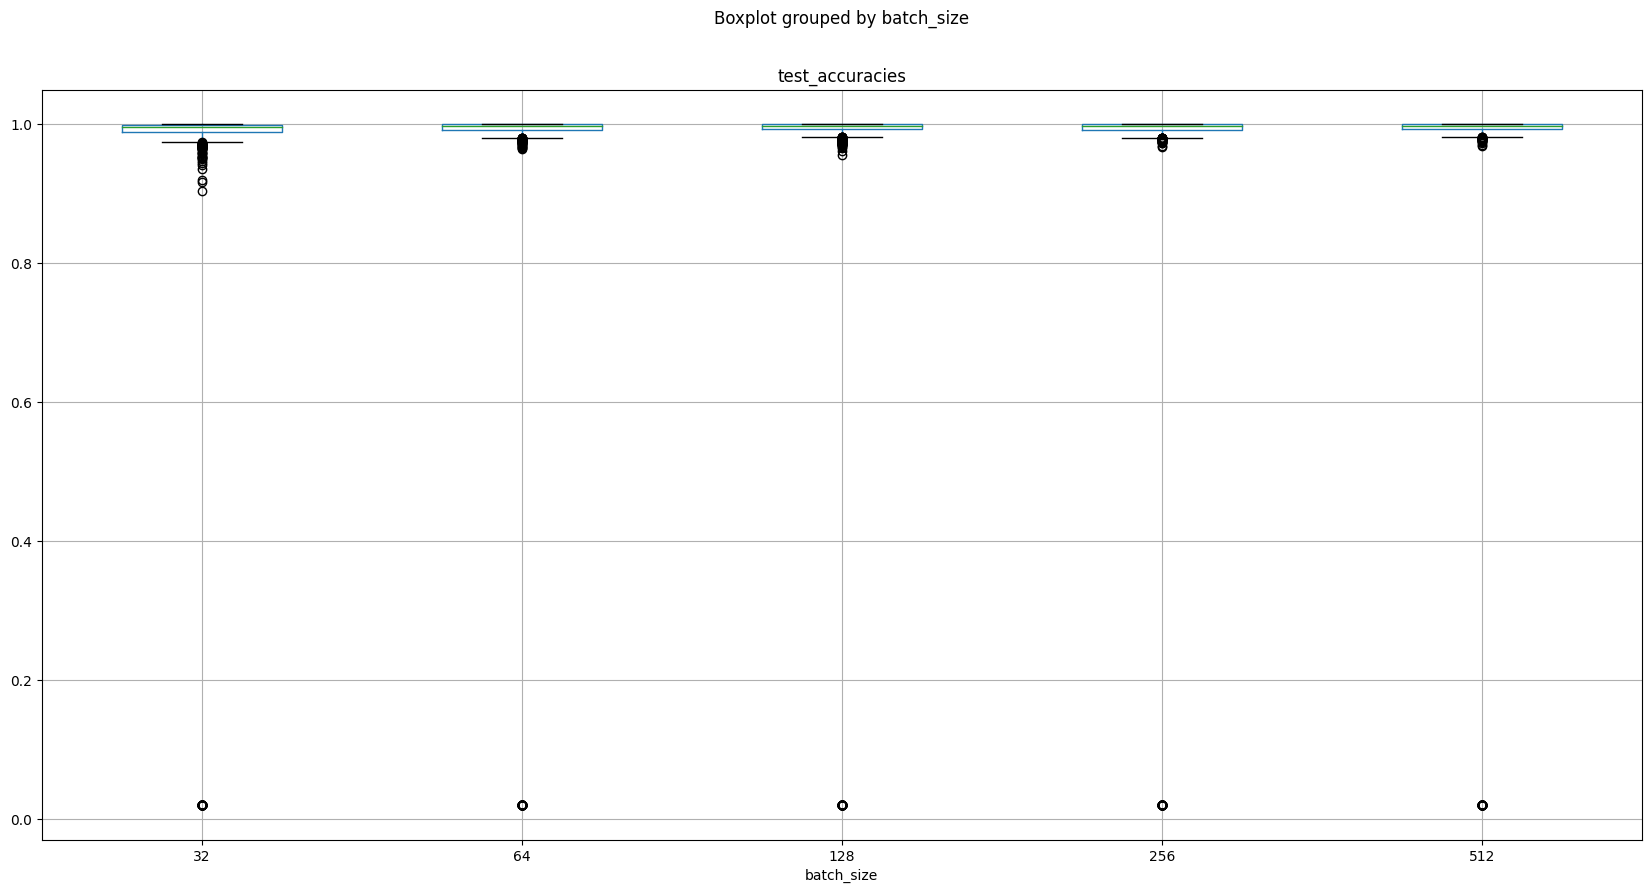

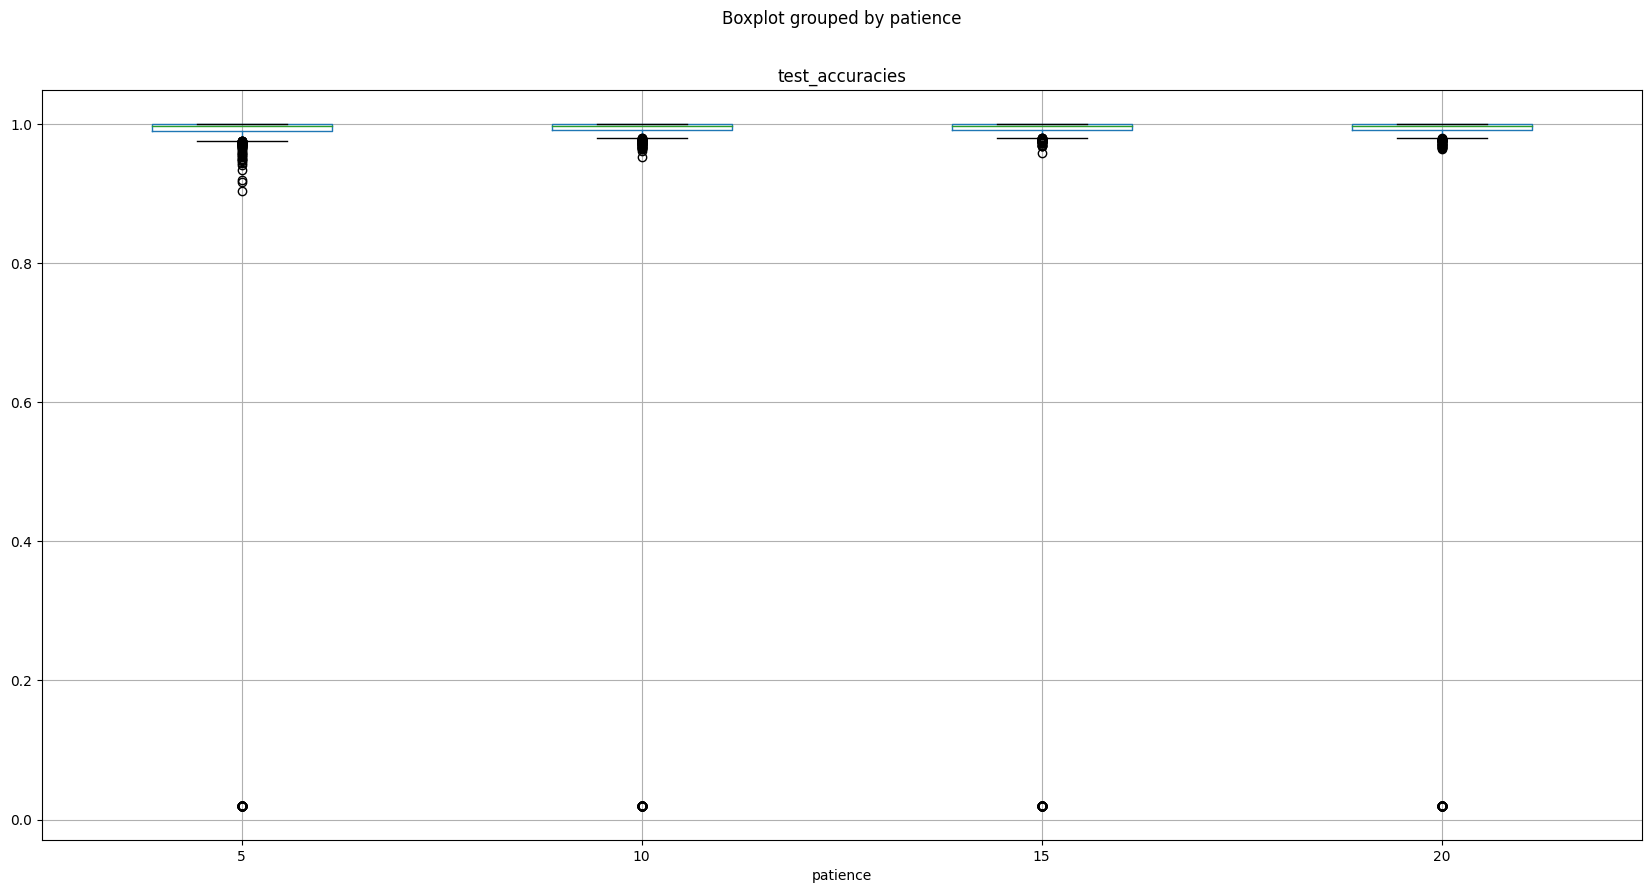

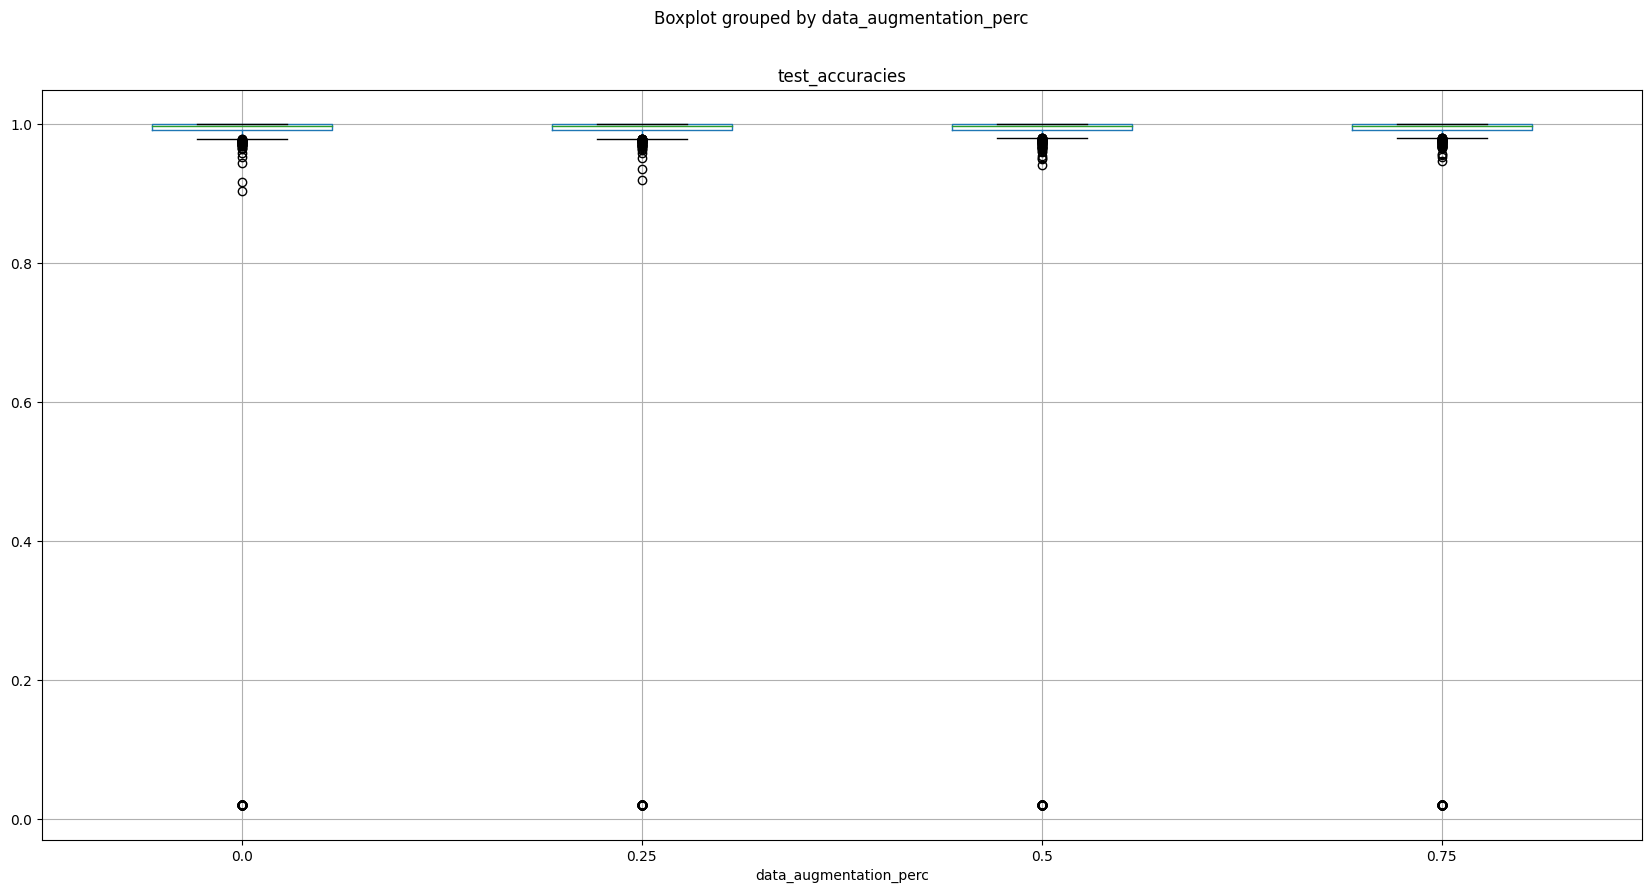

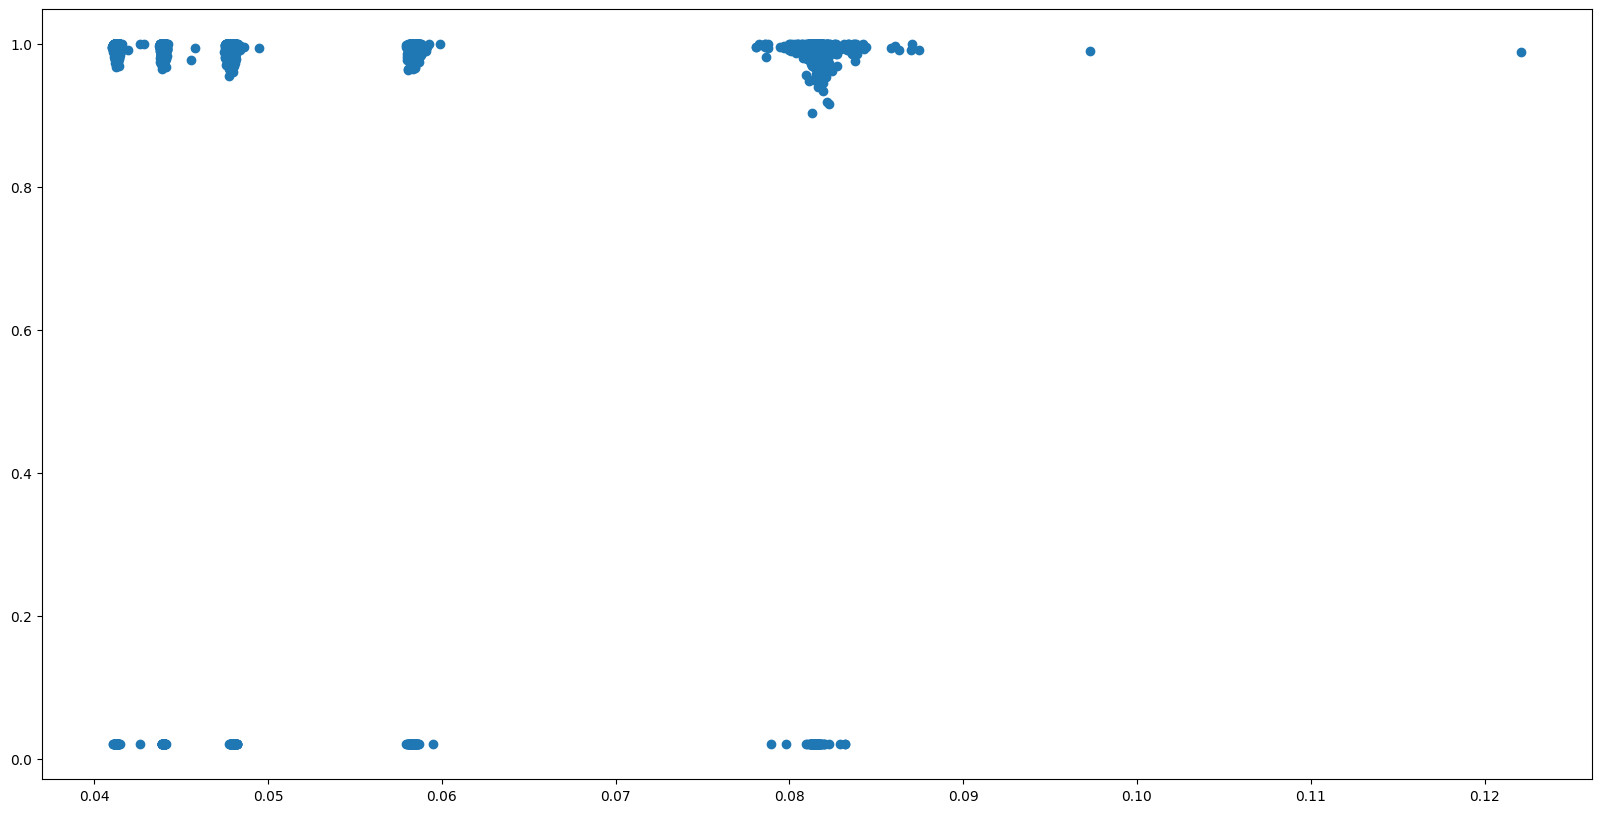

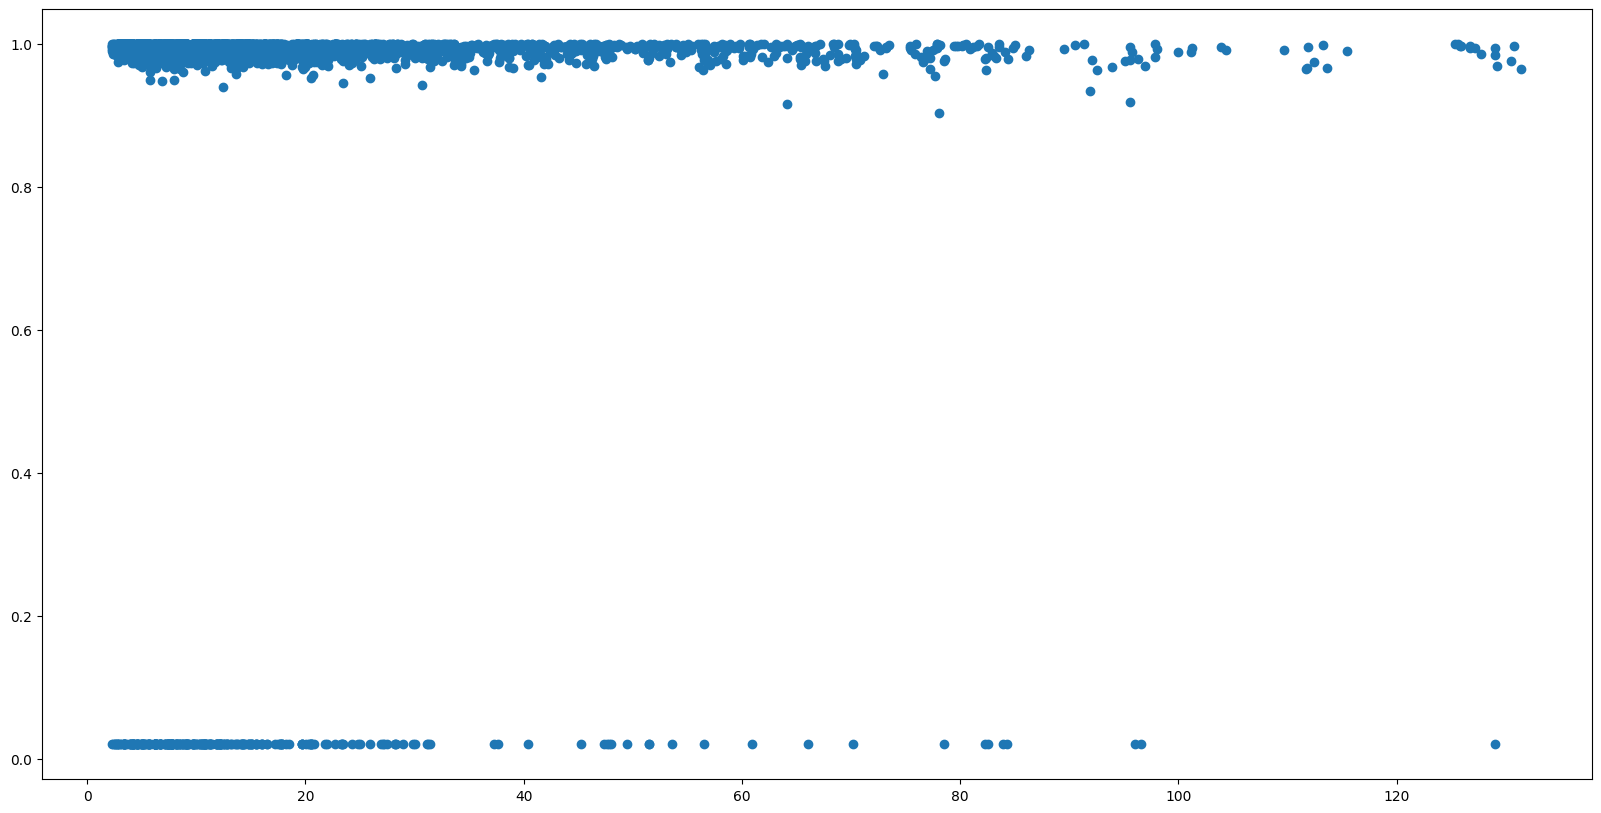

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
4571,290,14,1.0,"['Conv2', 'Conv3']",0.000001,256,5,0.50,1.0,0.043939,3.621892
1651,250,5,0.6,"['Conv2', 'Conv3']",0.000001,32,15,0.50,1.0,0.081411,17.349159
4193,232,13,0.6,"['Conv2', 'Conv3', 'FC1']",0.000010,512,15,0.00,1.0,0.041458,6.965916
4679,78,15,1.0,"['Conv2', 'FC1']",0.000500,512,20,0.50,1.0,0.041242,56.441647
1649,248,5,0.6,"['Conv2', 'Conv3']",0.000001,32,15,0.00,1.0,0.081305,23.737485
3301,300,10,0.6,"['Conv2', 'FC1']",0.000001,256,20,0.00,1.0,0.044052,10.689406
1650,249,5,0.6,"['Conv2', 'Conv3']",0.000001,32,15,0.25,1.0,0.081150,14.601301
3302,301,10,0.6,"['Conv2', 'FC1']",0.000001,256,20,0.25,1.0,0.044061,10.736172
3303,302,10,0.6,"['Conv2', 'FC1']",0.000001,256,20,0.50,1.0,0.043929,12.746789
3304,303,10,0.6,"['Conv2', 'FC1']",0.000001,256,20,0.75,1.0,0.043919,14.795997


In [7]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

591

In [8]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([14,  5, 13, 15, 10, 12,  2,  0])

In [9]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3']) (id: 14)
mean accuracy: 0.9992 with standard error: 0.0017

worst accuracy: 0.9847 with hyperparameters:
test_id                          1
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc        0.25
test_times                0.081921
train_times               5.686194
Name: 4282, dtype: object 

best accuracy: 1.0000 with hyperparameters:
test_id                         10
lr                          0.0005
batch_size                      32
patience                        15
data_augmentation_perc         0.5
test_times                0.081759
train_times               83.54464
Name: 4291, dtype: object 

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3']) (id: 5)
mean accuracy: 0.9994 with standard error: 0.0013

worst accuracy: 0.9886 with hyperparameters:
test_id    

In [10]:
best_model = NeuralNetwork.load_NN(all_results.iloc[7679], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

IndexError: single positional indexer is out-of-bounds

In [ ]:
best_model.return_stats()

,epochs,train_losses,eval_losses,test_accuracies,training_time_per_epoch
0,1,0.000266,0.0,1.0,0.645797


In [ ]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],0.00050,32,5,0.00,0.020078,0.078545,79.387270
218,218,0,2.0,['Conv2'],0.00001,256,15,0.50,0.020078,0.043728,0.605537
217,217,0,2.0,['Conv2'],0.00001,256,15,0.25,0.020078,0.043590,0.510674
216,216,0,2.0,['Conv2'],0.00001,256,15,0.00,0.020078,0.043718,0.415790
215,215,0,2.0,['Conv2'],0.00001,256,10,0.75,0.020078,0.043665,70.803141
214,214,0,2.0,['Conv2'],0.00001,256,10,0.50,0.020078,0.043732,0.606151
213,213,0,2.0,['Conv2'],0.00001,256,10,0.25,0.020078,0.043670,0.508479
212,212,0,2.0,['Conv2'],0.00001,256,10,0.00,0.020078,0.043509,0.414539
219,219,0,2.0,['Conv2'],0.00001,256,15,0.75,0.020078,0.043611,0.735349
211,211,0,2.0,['Conv2'],0.00001,256,5,0.75,0.020078,0.043459,0.696963


In [ ]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

320

In [ ]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0])

In [ ]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
test_id                          0
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 

best accuracy: 0.0201 with hyperparameters:
test_id                          0
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 



Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])_test_0


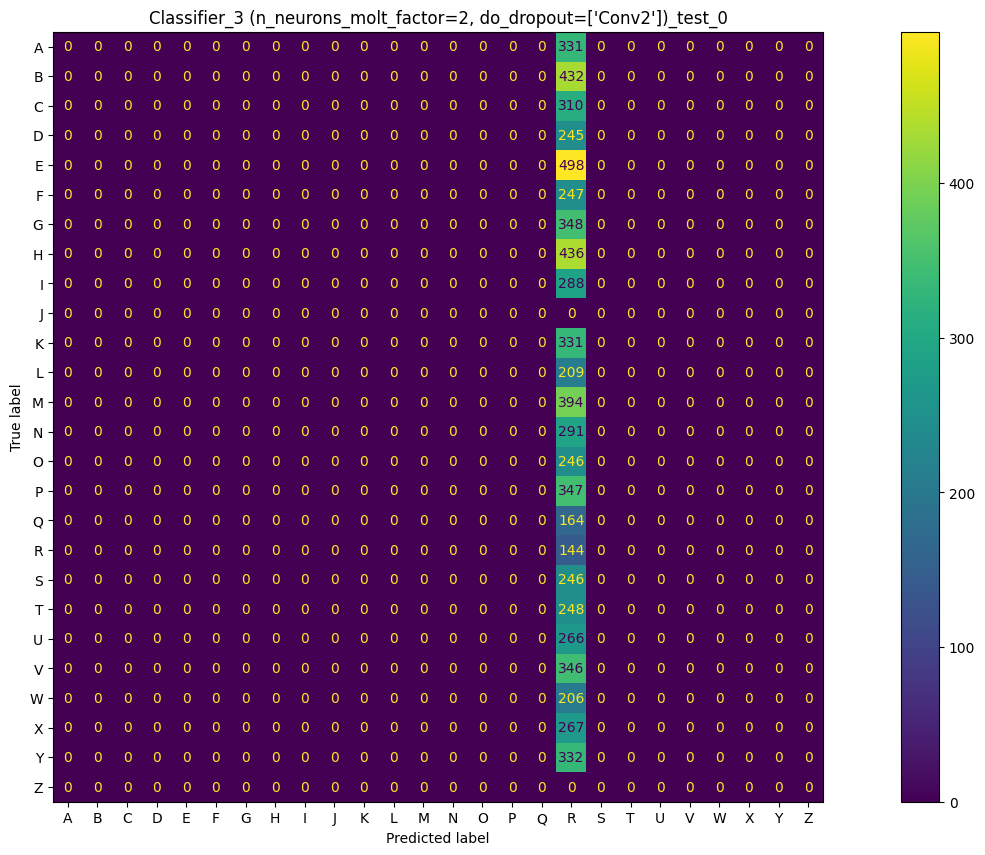

In [ ]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [ ]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
2880,0,9,2.0,[],0.0005,32,5,0.00,0.910904,0.077954,78.910970
4480,0,14,0.6,"['Conv3', 'FC1']",0.0005,32,5,0.00,0.917875,0.077965,18.235616
960,0,3,0.6,[],0.0005,32,5,0.00,0.920385,0.077508,78.074892
1600,0,5,1.0,[],0.0005,32,5,0.00,0.920943,0.077699,78.579071
961,1,3,0.6,[],0.0005,32,5,0.25,0.928193,0.077447,95.286937
2881,1,9,2.0,[],0.0005,32,5,0.25,0.930145,0.078176,96.361620
2561,1,8,2.0,['FC1'],0.0005,32,5,0.25,0.932376,0.078335,9.746702
1601,1,5,1.0,[],0.0005,32,5,0.25,0.935025,0.077141,95.793854
2560,0,8,2.0,['FC1'],0.0005,32,5,0.00,0.940045,0.078112,19.085825
2882,2,9,2.0,[],0.0005,32,5,0.50,0.941021,0.078050,30.691177


Classifier_3 (n_neurons_molt_factor=2, do_dropout=[])_test_0


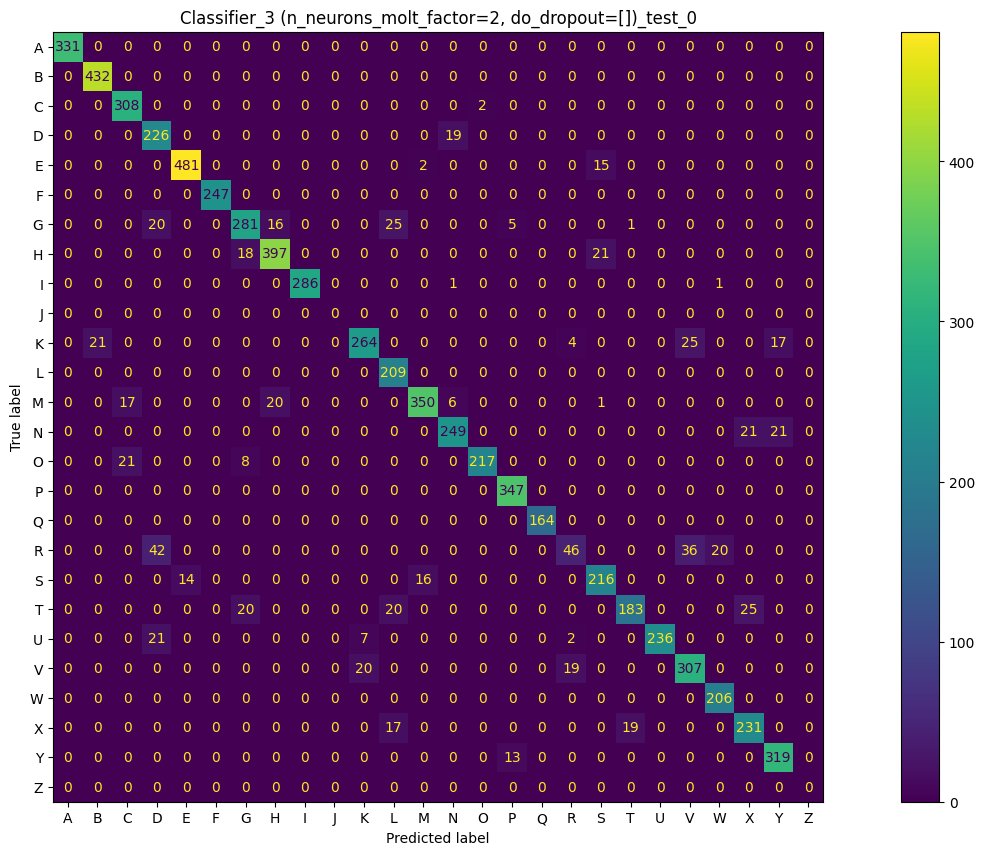

In [ ]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

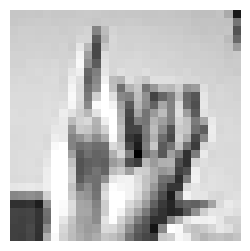

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [ ]:
image, response = sample_image(index = 10)
best_model.predict(image)